In [ ]:
!pip install --upgrade transformers accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 78.9 MB/s eta 0:00:00


In [ ]:
import os
from google.colab import drive
from dotenv import load_dotenv

drive.mount('/content/drive')

# 2. Define your specific project folder path
# CHANGE 'YOUR_FOLDER_NAME' to the exact name of your new folder
PROJECT_DIR = '/content/drive/MyDrive/internship_code'

# 3. MOVE INTO THE FOLDER (Change Working Directory)
os.chdir(PROJECT_DIR)
print(f"📂 Current working directory is now: {os.getcwd()}")

# 4. Load the secrets
# Because we moved into the folder, Python can just look right next to itself for '.env'
if os.path.exists('.env'):
    load_dotenv('.env')
    print("✅ .env file loaded successfully!")
else:
    print("❌ Could not find .env file. Are you sure you dragged it into this specific folder?")

# 5. Configure Hugging Face Cache (saving it inside your project folder to keep things tidy)
cache_dir = os.path.join(PROJECT_DIR, 'LLM_Cache')
os.makedirs(cache_dir, exist_ok=True)
os.environ['HF_HOME'] = cache_dir

if "HF_TOKEN" not in os.environ:
    print("⚠️ Warning: HF_TOKEN not found in environment! Check your .env file.")
else:
    print(f"✅ Hugging Face cache successfully configured at: {os.environ['HF_HOME']}")

Mounted at /content/drive
📂 Current working directory is now: /content/drive/MyDrive/internship_code
✅ .env file loaded successfully!
✅ Hugging Face cache successfully configured at: /content/drive/MyDrive/internship_code/LLM_Cache


In [ ]:
import torch
import transformers
import os
import shutil

# print("--- PRE-FLIGHT CLEANUP ---")

# 1. Wipe the old offload folder to prevent model collisions
offload_dir = "./model_offload"
if os.path.exists(offload_dir):
    shutil.rmtree(offload_dir)
os.makedirs(offload_dir, exist_ok=True)
print("✅ Offload folder sanitized.")

# # 2. Check for the local folder bug (from your plotting script)
# local_conflict = "Qwen"
# if os.path.exists(local_conflict):
#     shutil.rmtree(local_conflict)
#     print("✅ Local 'Qwen' ghost folder deleted.")

# 3. Set your Google Drive cache path
drive_cache = "/content/drive/MyDrive/internship_code/LLM_Cache"
os.makedirs(drive_cache, exist_ok=True)


model_checkpoint = "Qwen/Qwen3.5-2B"
#model_checkpoint = "google/gemma-4-E2B"
model_checkpoint = "Qwen/Qwen3.5-0.8B"
#model_checkpoint = "meta-llama/Llama-3.2-3B"
#model_checkpoint = "Qwen/Qwen2.5-Math-1.5B"
model_checkpoint_str = model_checkpoint.split("/")[-1]

print(f"\nLoading {model_checkpoint_str} from Google Drive...")

# 4. Load the model
model = transformers.AutoModelForCausalLM.from_pretrained(
    model_checkpoint,
    device_map="auto",
    dtype=torch.float16,
    offload_folder=offload_dir,
    cache_dir=drive_cache
)

tokenizer = transformers.AutoTokenizer.from_pretrained(
    model_checkpoint,
    cache_dir=drive_cache
)
model = model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

print(f"✅ Model successfully loaded!")

✅ Offload folder sanitized.

Loading Qwen3.5-0.8B from Google Drive...


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

✅ Model successfully loaded!


In [ ]:

import os, random, itertools
import numpy as np
import torch


MULT_CACHE_DIR = f"./mult_baseline/{model_checkpoint_str}"
os.makedirs(MULT_CACHE_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Current Device: {DEVICE}")
SEED   = 42
random.seed(SEED)
np.random.seed(SEED)

# Prompt format
def make_mult_prompt(a, b):
    return f"{a} * {b} = "

def digit_space_format(n):
    """'347' -> '3 4 7' — breaks BPE merges, forces single-digit tokens."""
    return " ".join(str(n))

# Prompt construction
def make_mult_prompt_spaced(a, b):
    return f"{digit_space_format(a)} * {digit_space_format(b)} = "

def make_mult_prompt_spaced(a, b):
    return (f"Compute {digit_space_format(a)} * {digit_space_format(b)}. "
            f"Output the answer with a space between each digit.\n"
            f"Answer: ")
# # ── Generate pairs by category ────────────────────────────────────────────────
# # Category 1: single × single (1-9 × 1-9), all 81 pairs
# # Products: 1–81, always 1-2 digits

s1_pairs = [(a, b)
            for a, b in itertools.product(range(1, 10), range(1, 10))]

s1_x_s2_pairs = [(a, b)
                 for a, b in itertools.product(range(1, 10), range(10, 100))]

# ALL 2×2 pairs — 8100 total, entirely feasible
all_s2_pairs = [(a, b)
                for a, b in itertools.product(range(10, 100), range(10, 100))]

# 2×3: sample 3000 stratified by product magnitude
# Stratify so you cover small and large products equally
all_s2_x_s3 = [(a, b)
               for a, b in itertools.product(range(10, 100), range(100, 1000))]
random.shuffle(all_s2_x_s3)
s2_x_s3_pairs = all_s2_x_s3[:3000]

# 3×3: sample 3000 — this is where column 4/5 errors come from
# At ~74% error rate you will get ~2200 failures → ~600+ column 4 errors
all_s3_pairs = [(a, b)
               for a, b in itertools.product(range(100, 1000), range(100, 1000))]
random.shuffle(all_s3_pairs)
s3_pairs = all_s3_pairs[:3000]

# NEW: add 2×4 (two-digit × four-digit)
# Products up to 99×9999 = 989,901 — six digits
# Gives you column 5 errors in meaningful quantity
# Model accuracy will be low (~20-30%) giving many failures
all_s2_x_s4 = [(a, b)
               for a, b in itertools.product(range(10, 100), range(1000, 10000))]
random.shuffle(all_s2_x_s4)
s2_x_s4_pairs = all_s2_x_s4[:1000]

# NEW: add 3×4 (three-digit × four-digit)
# Products up to 999×9999 = 9,989,001 — seven digits
# Gives column 6 errors
all_s3_x_s4 = [(a, b)
               for a, b in itertools.product(range(100, 1000), range(1000, 10000))]
random.shuffle(all_s3_x_s4)
s3_x_s4_pairs = all_s3_x_s4[:1000]

all_pairs = (
    [(a, b, "1x1")   for a, b in s1_pairs]       +
    [(a, b, "1x2")   for a, b in s1_x_s2_pairs]  +
    [(a, b, "2x2")   for a, b in all_s2_pairs]    +
    [(a, b, "2x3")   for a, b in s2_x_s3_pairs]  +
    [(a, b, "3x3")   for a, b in s3_pairs]        +
    [(a, b, "2x4")   for a, b in s2_x_s4_pairs]  +
    [(a, b, "3x4")   for a, b in s3_x_s4_pairs]
)

print(f"Total pairs: {len(all_pairs)}")
for cat in ["1x1", "1x2", "2x2", "2x3", "3x3", "2x4", "3x4"]:
    n = sum(1 for _, _, c in all_pairs if c == cat)
    print(f"  {cat}: {n}")





Current Device: cuda
Total pairs: 16991
  1x1: 81
  1x2: 810
  2x2: 8100
  2x3: 3000
  3x3: 3000
  2x4: 1000
  3x4: 1000


In [ ]:
sample_hard = [(a,b,cat) for a,b,cat in all_pairs if cat in ("2x3","3x3","2x4")][:15]
for a, b, cat in sample_hard:
    prompt = make_mult_prompt(a, b)
    enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=60, do_sample=False,
                              pad_token_id=tokenizer.pad_token_id)
    decoded = tokenizer.decode(out[0, enc.input_ids.shape[1]:], skip_special_tokens=True)
    print(f"{a}*{b}= -> {decoded[:150]!r}\n")

36*580= -> '20880\n36 * 580 = 20880\n36 * 580 = 20880\n36 * 580 = 20880\n36 * 580 = '

44*627= -> '2768\n44 * 627 = 2768\n44 * 627 = 2768\n44 * 627 = 2768\n44 * 627 = 2768'

95*210= -> '19950\n19950 / 210 = 95\n95 * 210 = 19950\n19950 / 210 = 95\n95 * 210 = '

75*296= -> '22200\n22200 / 296 = 75\n75 * 296 = 22200\n22200 / 296 = 75\n75 * 296 = '

87*892= -> '77584\n892 * 87 = 77584\n87 * 892 = 77584\n892 * 87 = 77584\n87 * 892 = '

11*818= -> '8998\n11 * 819 = 9009\n11 * 820 = 9010\n11 * 821 = 9021\n11 * 822 = 9032'

65*150= -> '9750\n65 * 150 = 9750\n65 * 150 = 9750\n65 * 150 = 9750\n65 * 150 = 9750'

27*332= -> '8964\n27 * 332 = 8964\n27 * 332 = 8964\n27 * 332 = 8964\n27 * 332 = 8964'

38*516= -> '19608\n19608 / 516 = 38\n38 * 516 = 19608\n19608 / 516 = 38\n38 * 516 = '

89*341= -> '30339\n30339 + 341 = 30680\n30680 + 341 = 31021\n31021 + 341 = 31362\n'

28*997= -> '27916\n27916 / 28 = 997.0000000000001\n27916 / 28 = 997.0000000000'

64*528= -> '33776\n33776 / 528 = 63.80909090909091\

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Batched Generation & Answer Parsing                        ║
# ╚══════════════════════════════════════════════════════════════════════╝
# Since multiplication can produce answers with multiple digits we must
# carefully parse the answer generated by the model
#
# Answer parsing strategy:
#   Extract the first contiguous run of digits from the generated text.
#   This handles cases like "56\n", "56 ", "= 56", " 56 (correct)" etc.
#   Compare as integer to ground truth.
#
# Why max_new_tokens=8?
#   Largest possible answer is 999×999=998001 (6 digits).
#   We add 2 tokens of buffer for any leading space or separator.

import re
import time

GENERATE_BATCH = 64    # conservative — generation is more memory-intensive
                        # than a single forward pass; reduce to 8 if OOM

def parse_answer(generated_str):
    """
    Extract the first integer from a generated string.
    Returns None if no integer found.

    Examples:
      "56"        → 56
      "56\n"      → 56
      " 56 = ..." → 56
      "fifty-six" → None
    """
    # Remove commas and spaces that models use for thousands separators
    sanitized = re.sub(r'[, ]', '', generated_str)
    match = re.search(r'\d+', sanitized)
    if match:
        return int(match.group())
    return None


model_answers  = []    # what the model generated (parsed integer or None)
ground_truths  = []    # correct products
categories     = []    # "1x1", "1x2", "2x2", "2x3", "3x3"
operand_pairs  = []    # (a, b) for each example
raw_outputs    = []    # decoded string before parsing (for debugging)

t0 = time.time()
n_total = len(all_pairs)

for start in range(0, n_total, GENERATE_BATCH):
    batch     = all_pairs[start : start + GENERATE_BATCH]
    prompts   = [make_mult_prompt(a, b) for a, b, _ in batch]
    bsz       = len(batch)

    enc = tokenizer(
        prompts, return_tensors="pt",
        padding=True, truncation=True
    ).to(DEVICE)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=10,
            do_sample=False,                    # greedy — deterministic low Temp.
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode only the newly generated tokens (not the prompt)
    prompt_len = enc.input_ids.shape[1]
    for j in range(bsz):
        new_tokens   = out[j, prompt_len:]
        decoded      = tokenizer.decode(new_tokens, skip_special_tokens=True)
        parsed       = parse_answer(decoded)
        a, b, cat    = batch[j]
        correct      = a * b

        model_answers.append(parsed)
        ground_truths.append(correct)
        categories.append(cat)
        operand_pairs.append((a, b))
        raw_outputs.append(decoded)

    del enc, out
    torch.cuda.empty_cache()

    if start % 160 == 0:
        elapsed = time.time() - t0
        pct     = (start + bsz) / n_total
        eta     = (elapsed / max(pct, 1e-6)) * (1 - pct)
        print(f"  {start+bsz:>4}/{n_total} | elapsed={elapsed:.0f}s | ETA={eta:.0f}s")

# Convert to arrays
model_answers_arr = np.array([x if x is not None else -1 for x in model_answers])
ground_truths_arr = np.array(ground_truths)
categories_arr    = np.array(categories)
correct_arr       = (model_answers_arr == ground_truths_arr)

# Save
np.save(os.path.join(MULT_CACHE_DIR, "model_answers.npy"),  model_answers_arr)
np.save(os.path.join(MULT_CACHE_DIR, "ground_truths.npy"),  ground_truths_arr)
np.save(os.path.join(MULT_CACHE_DIR, "categories.npy"),     categories_arr)
np.save(os.path.join(MULT_CACHE_DIR, "correct.npy"),        correct_arr)
np.save(os.path.join(MULT_CACHE_DIR, "operand_pairs.npy"),
        np.array(operand_pairs))

print(f"\nTotal time: {time.time()-t0:.0f}s")
print(f"Parse failures (no integer found): "
      f"{sum(1 for x in model_answers if x is None)}")


    64/16991 | elapsed=2s | ETA=477s
   384/16991 | elapsed=10s | ETA=423s
   704/16991 | elapsed=17s | ETA=404s
  1024/16991 | elapsed=25s | ETA=397s
  1344/16991 | elapsed=33s | ETA=386s
  1664/16991 | elapsed=41s | ETA=377s
  1984/16991 | elapsed=49s | ETA=369s
  2304/16991 | elapsed=57s | ETA=360s
  2624/16991 | elapsed=64s | ETA=352s
  2944/16991 | elapsed=72s | ETA=344s
  3264/16991 | elapsed=80s | ETA=337s
  3584/16991 | elapsed=88s | ETA=329s
  3904/16991 | elapsed=96s | ETA=321s
  4224/16991 | elapsed=104s | ETA=313s
  4544/16991 | elapsed=111s | ETA=305s
  4864/16991 | elapsed=119s | ETA=297s
  5184/16991 | elapsed=127s | ETA=289s
  5504/16991 | elapsed=135s | ETA=281s
  5824/16991 | elapsed=143s | ETA=274s
  6144/16991 | elapsed=151s | ETA=266s
  6464/16991 | elapsed=158s | ETA=258s
  6784/16991 | elapsed=166s | ETA=250s
  7104/16991 | elapsed=174s | ETA=242s
  7424/16991 | elapsed=182s | ETA=234s
  7744/16991 | elapsed=190s | ETA=226s
  8064/16991 | elapsed=197s | ETA=219s


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 (Llama digit-spaced variant) — Batched Generation & Parsing  ║
# ╚══════════════════════════════════════════════════════════════════════╝
import re
import time

GENERATE_BATCH = 64

# ── NEW: digit-spacing helpers ────────────────────────────────────────────────
def digit_space_format(n):
    """'347' -> '3 4 7'"""
    return " ".join(str(n))

def make_mult_prompt_spaced(a, b):
    """
    CHANGED from make_mult_prompt: operands are digit-spaced, and the model
    is explicitly instructed to answer in the same format. Without the
    explicit instruction, the model will likely default back to its native
    merged-digit output style even though the input was spaced — conflating
    two different interventions (input tokenization vs output tokenization).
    """
    return (f"Compute {digit_space_format(a)} * {digit_space_format(b)}. "
            f"Give the answer with a single space between every digit, "
            f"and no other text.\nAnswer: ")

# ── CHANGED: parser must handle "5 6" not "56" ────────────────────────────────
def parse_answer_spaced(generated_str):
    r"""
    Extract a digit-spaced integer from generated text.

    Fix: operate on the FIRST LINE only (splits on newline before any
    regex matching), and match on literal single spaces only — not \s —
    so digits from separate lines can never be stitched together.
    """
    first_line = generated_str.strip().split("\n")[0]

    spaced_match = re.search(r'\b(\d(?: \d)*)\b', first_line)
    if spaced_match:
        digits_only = spaced_match.group(1).replace(" ", "")
        if digits_only:
            try:
                return int(digits_only), False
            except ValueError:
                pass

    sanitized = re.sub(r'[,\s]', '', generated_str)
    match = re.search(r'\d+', sanitized)
    if match:
        try:
            return int(match.group()), True
        except ValueError:
            pass

    return None, False


model_answers   = []
ground_truths   = []
categories      = []
operand_pairs   = []
raw_outputs     = []
fallback_flags  = []   # NEW: track whether spaced-parsing succeeded or fell back

t0 = time.time()
n_total = len(all_pairs)

for start in range(0, n_total, GENERATE_BATCH):
    batch   = all_pairs[start : start + GENERATE_BATCH]
    prompts = [make_mult_prompt_spaced(a, b) for a, b, _ in batch]   # CHANGED
    bsz     = len(batch)

    # NEW: left-padding required for correct batched generation on a causal LM
    tokenizer.padding_side = "left"
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    enc = tokenizer(
        prompts, return_tensors="pt",
        padding=True, truncation=True
    ).to(DEVICE)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=20,   # CHANGED from 10: spaced digits roughly
                                  # double token count (each digit + each
                                  # space may be separate tokens), plus
                                  # room for the model's natural verbosity
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,   # CHANGED: use pad_token_id
                                                     # not eos_token_id directly,
                                                     # in case they differ
        )

    prompt_len = enc.input_ids.shape[1]
    for j in range(bsz):
        new_tokens = out[j, prompt_len:]
        decoded    = tokenizer.decode(new_tokens, skip_special_tokens=True)
        #parsed, used_fallback = parse_answer_spaced(decoded)   # CHANGED
        try:
            parsed, used_fallback = parse_answer_spaced(decoded)
        except Exception as e:
            print(f"Parse error at index {start+j}: {e!r} | raw: {decoded!r}")
            parsed, used_fallback = None, False
        a, b, cat  = batch[j]
        correct    = a * b

        model_answers.append(parsed)
        ground_truths.append(correct)
        categories.append(cat)
        operand_pairs.append((a, b))
        raw_outputs.append(decoded)
        fallback_flags.append(used_fallback)   # NEW

    del enc, out
    torch.cuda.empty_cache()

    if start % 160 == 0:
        elapsed = time.time() - t0
        pct     = (start + bsz) / n_total
        eta     = (elapsed / max(pct, 1e-6)) * (1 - pct)
        print(f"  {start+bsz:>4}/{n_total} | elapsed={elapsed:.0f}s | ETA={eta:.0f}s")

model_answers_arr  = np.array([x if x is not None else -1 for x in model_answers])
ground_truths_arr  = np.array(ground_truths)
categories_arr     = np.array(categories)
correct_arr        = (model_answers_arr == ground_truths_arr)
fallback_arr        = np.array(fallback_flags)   # NEW

LLAMA_SPACED_DIR = os.path.join(MULT_CACHE_DIR, "llama_spaced")
os.makedirs(LLAMA_SPACED_DIR, exist_ok=True)

np.save(os.path.join(LLAMA_SPACED_DIR, "model_answers.npy"), model_answers_arr)
np.save(os.path.join(LLAMA_SPACED_DIR, "ground_truths.npy"), ground_truths_arr)
np.save(os.path.join(LLAMA_SPACED_DIR, "categories.npy"), categories_arr)
np.save(os.path.join(LLAMA_SPACED_DIR, "correct.npy"), correct_arr)
np.save(os.path.join(LLAMA_SPACED_DIR, "operand_pairs.npy"), np.array(operand_pairs))
np.save(os.path.join(LLAMA_SPACED_DIR, "fallback_flags.npy"), fallback_arr)   # NEW

print(f"\nTotal time: {time.time()-t0:.0f}s")
print(f"Parse failures (no integer found): {sum(1 for x in model_answers if x is None)}")
print(f"Fallback rate (ignored spacing instruction): {fallback_arr.mean():.1%}")   # NEW

    64/16991 | elapsed=3s | ETA=713s
   384/16991 | elapsed=16s | ETA=675s
   704/16991 | elapsed=29s | ETA=662s
  1024/16991 | elapsed=42s | ETA=648s
  1344/16991 | elapsed=54s | ETA=629s
  1664/16991 | elapsed=66s | ETA=609s
  1984/16991 | elapsed=78s | ETA=589s
  2304/16991 | elapsed=90s | ETA=571s
  2624/16991 | elapsed=102s | ETA=556s
  2944/16991 | elapsed=114s | ETA=543s
  3264/16991 | elapsed=126s | ETA=531s
  3584/16991 | elapsed=139s | ETA=519s
  3904/16991 | elapsed=153s | ETA=513s
  4224/16991 | elapsed=165s | ETA=499s
  4544/16991 | elapsed=177s | ETA=485s
  4864/16991 | elapsed=189s | ETA=472s
  5184/16991 | elapsed=201s | ETA=459s
  5504/16991 | elapsed=214s | ETA=446s
  5824/16991 | elapsed=226s | ETA=433s
  6144/16991 | elapsed=238s | ETA=420s
  6464/16991 | elapsed=250s | ETA=408s
  6784/16991 | elapsed=263s | ETA=395s
  7104/16991 | elapsed=275s | ETA=382s
  7424/16991 | elapsed=287s | ETA=370s
  7744/16991 | elapsed=299s | ETA=357s
  8064/16991 | elapsed=311s | ETA=

╔══════════════════════════════════════════════════════╗
║  Multiplication Baseline — Qwen2.5-Math-1.5B        ║
╠══════════════════════════════════════════════════════╣
  1x1:  100.0% accurate  (0 failures / 81 examples)
  1x2:  84.8% accurate  (123 failures / 810 examples)
  2x2:  76.4% accurate  (1909 failures / 8100 examples)
  2x3:  35.0% accurate  (1951 failures / 3000 examples)
  3x3:  9.3% accurate  (2721 failures / 3000 examples)
  2x4:  23.7% accurate  (763 failures / 1000 examples)
  3x4:  3.1% accurate  (969 failures / 1000 examples)
  Overall: 50.4%
╚══════════════════════════════════════════════════════╝

── Error type breakdown ──
  1x2 failures (n=123):
    Off by multiple of 10:       75 (61.0%)
    Off by ≤5:      0 (0.0%)
    Off by >10:     122 (99.2%)
  2x2 failures (n=1909):
    Off by multiple of 10:       1469 (77.0%)
    Off by ≤5:      11 (0.6%)
    Off by >10:     1858 (97.3%)
  2x3 failures (n=1951):
    Off by multiple of 10:       1481 (75.9%)
    Off by ≤

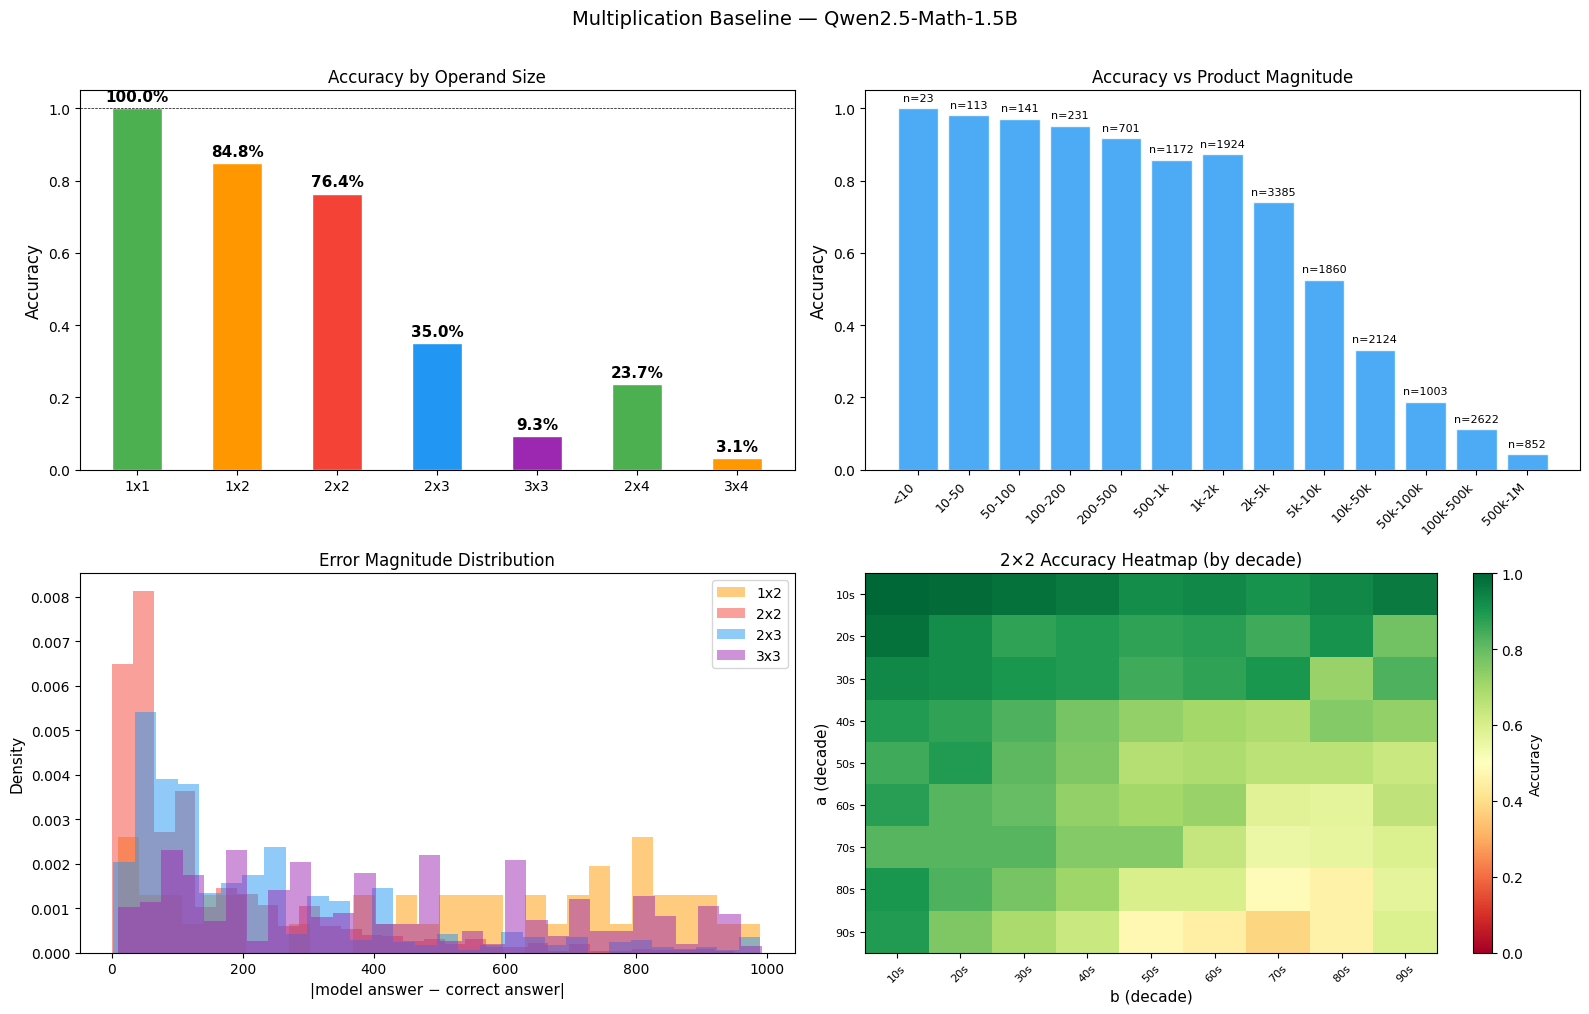


── Sample outputs (first 5 of each category) ──

  1x1:
    1 * 1 = 1  (correct: 1) ✓
    1 * 2 = 2  (correct: 2) ✓
    1 * 3 = 3  (correct: 3) ✓
    1 * 4 = 4  (correct: 4) ✓
    1 * 5 = 5  (correct: 5) ✓

  1x2:
    1 * 10 = 10  (correct: 10) ✓
    1 * 11 = 110  (correct: 11) ✗
    1 * 12 = 12  (correct: 12) ✓
    1 * 13 = 13  (correct: 13) ✓
    1 * 14 = 14  (correct: 14) ✓

  2x2:
    10 * 10 = 100  (correct: 100) ✓
    10 * 11 = 110  (correct: 110) ✓
    10 * 12 = 120  (correct: 120) ✓
    10 * 13 = 130  (correct: 130) ✓
    10 * 14 = 140  (correct: 140) ✓

  2x3:
    36 * 580 = 20880  (correct: 20880) ✓
    44 * 627 = 251808  (correct: 27588) ✗
    95 * 210 = 19950  (correct: 19950) ✓
    75 * 296 = 22200  (correct: 22200) ✓
    87 * 892 = 1000000000  (correct: 77604) ✗

  3x3:
    468 * 813 = 378018  (correct: 380484) ✗
    578 * 733 = 419004  (correct: 423674) ✗
    326 * 802 = 261552  (correct: 261452) ✗
    388 * 992 = 380096  (correct: 384896) ✗
    476 * 982 = 466672  (cor

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Accuracy Summary & Failure Curve                         ║
# ╚══════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle

model_answers_arr = np.load(os.path.join(MULT_CACHE_DIR, "model_answers.npy"), allow_pickle=True)
ground_truths_arr = np.load(os.path.join(MULT_CACHE_DIR, "ground_truths.npy"), allow_pickle=True)
categories_arr    = np.load(os.path.join(MULT_CACHE_DIR, "categories.npy"), allow_pickle=True)
correct_arr       = np.load(os.path.join(MULT_CACHE_DIR, "correct.npy"), allow_pickle=True)
operand_pairs_arr = np.load(os.path.join(MULT_CACHE_DIR, "operand_pairs.npy"), allow_pickle=True)

# ── Per-category accuracy ─────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════╗")
print(f"║  Multiplication Baseline — {model_checkpoint_str}        ║")
print("╠══════════════════════════════════════════════════════╣")
for cat in ["1x1", "1x2", "2x2", "2x3", "3x3", "2x4", "3x4"]:
    mask = categories_arr == cat
    acc  = correct_arr[mask].mean()
    n    = mask.sum()
    fail = (~correct_arr[mask]).sum()
    print(f"  {cat}:  {acc:.1%} accurate  "
          f"({int(fail)} failures / {n} examples)")
print(f"  Overall: {correct_arr.mean():.1%}")
print("╚══════════════════════════════════════════════════════╝")

# ── Error analysis: what does the model predict when wrong? ───────────────────
print("\n── Error type breakdown ──")
for cat in ["1x1", "1x2", "2x2", "2x3", "3x3", "2x4", "3x4"]:
    mask    = (categories_arr == cat) & ~correct_arr
    if mask.sum() == 0:
        continue
    errors  = model_answers_arr[mask] - ground_truths_arr[mask]
    off_by_1 = (np.abs(errors) % 10 == 0).sum()
    off_by_small = (np.abs(errors) <= 5).sum()
    large   = (np.abs(errors) > 10).sum()
    print(f"  {cat} failures (n={mask.sum()}):")
    print(f"    Off by multiple of 10:       {off_by_1} ({off_by_1/mask.sum():.1%})")
    print(f"    Off by ≤5:      {off_by_small} ({off_by_small/mask.sum():.1%})")
    print(f"    Off by >10:     {large} ({large/mask.sum():.1%})")

# ── Failure curve: accuracy vs product magnitude ──────────────────────────────
# Bin products into ranges and plot accuracy per bin
# This is your baseline failure curve — shows where difficulty increases

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# Top left: accuracy by category (bar chart)
ax1 = fig.add_subplot(gs[0, 0])
cat_labels = ["1x1", "1x2", "2x2", "2x3", "3x3", "2x4", "3x4"]
cat_accs   = [correct_arr[categories_arr==c].mean() for c in ["1x1", "1x2", "2x2", "2x3", "3x3", "2x4", "3x4"]]
colours = ["#4CAF50", "#FF9800", "#F44336", "#2196F3", "#9C27B0"]
bars = ax1.bar(cat_labels, cat_accs, color=colours, edgecolor="white", width=0.5)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.set_ylim(0, 1.05)
ax1.set_title("Accuracy by Operand Size", fontsize=12)
ax1.axhline(1.0, color="black", linewidth=0.5, linestyle="--")
for bar, acc in zip(bars, cat_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, acc + 0.02,
             f"{acc:.1%}", ha="center", fontsize=11, fontweight="bold")

# Top right: accuracy vs product magnitude (binned)
ax2 = fig.add_subplot(gs[0, 1])
bins      = [0, 10, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 50000, 100000, 500000, 1000000]
bin_labels= ["<10","10-50","50-100","100-200","200-500",
             "500-1k","1k-2k","2k-5k","5k-10k", "10k-50k", "50k-100k", "100k-500k", "500k-1M"]
bin_accs  = []
bin_counts= []
for i in range(len(bins)-1):
    mask = (ground_truths_arr >= bins[i]) & (ground_truths_arr < bins[i+1])
    if mask.sum() > 0:
        bin_accs.append(correct_arr[mask].mean())
        bin_counts.append(mask.sum())
    else:
        bin_accs.append(np.nan)
        bin_counts.append(0)

x_pos = range(len(bin_labels))
ax2.bar(x_pos, bin_accs, color="#2196F3", alpha=0.8, edgecolor="white")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.set_title("Accuracy vs Product Magnitude", fontsize=12)
# Annotate with counts
for i, (acc, cnt) in enumerate(zip(bin_accs, bin_counts)):
    if not np.isnan(acc):
        ax2.text(i, acc + 0.02, f"n={cnt}", ha="center", fontsize=8)

# Bottom left: error magnitude distribution per category
ax3 = fig.add_subplot(gs[1, 0])
for cat, col in zip(["1x1", "1x2", "2x2", "2x3", "3x3", "2x4", "3x4"], colours):
    mask   = (categories_arr == cat) & ~correct_arr
    if mask.sum() == 0:
        continue
    errors = np.abs(model_answers_arr[mask] - ground_truths_arr[mask])
    errors = errors[errors < 1000]   # clip extreme outliers for visibility
    ax3.hist(errors, bins=30, alpha=0.5, color=col, label=cat, density=True)
ax3.set_xlabel("|model answer − correct answer|", fontsize=11)
ax3.set_ylabel("Density", fontsize=11)
ax3.set_title("Error Magnitude Distribution", fontsize=12)
ax3.legend()

# Bottom right: 2x2 heatmap — accuracy per (a, b) cell
ax4 = fig.add_subplot(gs[1, 1])
mask_2x2  = categories_arr == "2x2"
pairs_2x2 = operand_pairs_arr[mask_2x2]
corr_2x2  = correct_arr[mask_2x2]

# Build accuracy grid (10-99 is too fine — bucket into decades)
decade_a  = (pairs_2x2[:, 0] // 10).astype(int)   # 1-9 (for 10-19, 20-29...)
decade_b  = (pairs_2x2[:, 1] // 10).astype(int)
grid_acc  = np.full((10, 10), np.nan)
for da in range(1, 10):
    for db in range(1, 10):
        cell_mask = (decade_a == da) & (decade_b == db)
        if cell_mask.sum() > 0:
            grid_acc[da, db] = corr_2x2[cell_mask].mean()

im = ax4.imshow(grid_acc[1:, 1:], cmap="RdYlGn", vmin=0, vmax=1,
                aspect="auto")
ax4.set_xticks(range(9))
ax4.set_yticks(range(9))
ax4.set_xticklabels([f"{d*10}s" for d in range(1, 10)], rotation=45, fontsize=8)
ax4.set_yticklabels([f"{d*10}s" for d in range(1, 10)], fontsize=8)
ax4.set_xlabel("b (decade)", fontsize=11)
ax4.set_ylabel("a (decade)", fontsize=11)
ax4.set_title("2×2 Accuracy Heatmap (by decade)", fontsize=12)
plt.colorbar(im, ax=ax4, label="Accuracy")

fig.suptitle(f"Multiplication Baseline — {model_checkpoint_str}", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(MULT_CACHE_DIR, "baseline_failure_curve.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── Spot-check raw outputs for sanity ────────────────────────────────────────
# Always worth checking a few actual model generations before trusting numbers
print("\n── Sample outputs (first 5 of each category) ──")
for cat in ["1x1", "1x2", "2x2", "2x3", "3x3", "2x4", "3x4"]:
    print(f"\n  {cat}:")
    shown = 0
    for i in range(len(categories_arr)):
        if categories_arr[i] == cat and shown < 5:
            a, b   = operand_pairs_arr[i]
            gt     = int(ground_truths_arr[i])
            pred   = int(model_answers_arr[i])
            marker = "✓" if correct_arr[i] else "✗"
            print(f"    {a} * {b} = {pred}  (correct: {gt}) {marker}")
            shown += 1

In [ ]:
model_checkpoint = "Qwen/Qwen3.5-0.8B"
model_checkpoint = "Qwen/Qwen3.5-2B"
model_checkpoint = "Qwen/Qwen3.5-4B"
model_checkpoint = "meta-llama/Llama-3.2-3B"
model_checkpoint = "Qwen/Qwen2.5-Math-1.5B"
model_checkpoint = "Qwen/Qwen3.5-2B"
model_checkpoint_str = model_checkpoint.split("/")[-1]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
from scipy.optimize import curve_fit
import os

MULT_CACHE_DIR    = f"./mult_baseline/{model_checkpoint_str}"
model_answers_arr = np.load(os.path.join(MULT_CACHE_DIR, "model_answers.npy"), allow_pickle=True)
ground_truths_arr = np.load(os.path.join(MULT_CACHE_DIR, "ground_truths.npy"), allow_pickle=True)
categories_arr    = np.load(os.path.join(MULT_CACHE_DIR, "categories.npy"), allow_pickle=True)
correct_arr       = np.load(os.path.join(MULT_CACHE_DIR, "correct.npy"), allow_pickle=True)
operand_pairs_arr = np.load(os.path.join(MULT_CACHE_DIR, "operand_pairs.npy"), allow_pickle=True)
print(MULT_CACHE_DIR)


./mult_baseline/Qwen3.5-2B


In [ ]:

print("Ground truth digit parity distribution:")
for k in range(6):
    gt_d_k = (ground_truths_arr // (10**k)) % 10
    even_gt = (gt_d_k % 2 == 0).mean()
    print(f"  Column {k}: {even_gt:.3f} even "
          f"({'expected ~0.75 from multiplication structure' if k==0 else ''})")

# And check: does the 75% even ground truth at units column
# explain the high even error rate there?
# If gt is even and pred is random, error parity = (gt parity XOR pred parity)
# P(error even) = P(pred even | gt even)*P(gt even) + P(pred odd | gt odd)*P(gt odd)
# Under uniform random pred (excluding gt):
# P(pred even | gt even) = 4/9 (4 even digits ≠ gt_d in 0-9)
# P(pred odd  | gt odd)  = 5/9 (5 odd digits in 0-9, all ≠ gt_d since gt_d is odd)
# So:
# P(error even) = (4/9)*0.75 + (5/9)*0.25
#               = 0.333 + 0.139 = 0.472

p_error_even_null_units = (4/9)*0.75 + (4/9)*0.25
print(f"\nNull P(error even) at units column given 75% even gt: "
      f"{p_error_even_null_units:.3f}")
print(f"Observed at units column: 0.848")
print(f"Excess above this null:   {0.848 - p_error_even_null_units:+.3f}")

# More carefully: for each column and each example,
# compute the null expectation accounting for the actual gt_d value
for k in range(6):
    gt_d_k   = (ground_truths_arr // (10**k)) % 10
    safe_pred = np.where(model_answers_arr < 0, -999, model_answers_arr)
    pred_d_k  = (safe_pred // (10**k)) % 10
    valid     = model_answers_arr >= 0
    wrong     = valid & (gt_d_k != pred_d_k) & ~correct_arr

    if wrong.sum() < 5:
        continue

    null_rates = []
    for gt_d in gt_d_k[wrong]:
        # All possible non-gt digits
        possible_digits = [d for d in range(10) if d != gt_d]
        possible_errors = [d - gt_d for d in possible_digits]
        # Fraction of possible errors that are even
        even_frac = sum(1 for e in possible_errors if e % 2 == 0) / len(possible_errors)
        null_rates.append(even_frac)

    observed    = ((pred_d_k[wrong] - gt_d_k[wrong]) % 2 == 0).mean()
    null_exp    = np.mean(null_rates)
    gt_even_frac = (gt_d_k[wrong] % 2 == 0).mean()

    print(f"Column {k}: observed={observed:.3f}  "
          f"null={null_exp:.3f}  "
          f"excess={observed-null_exp:+.3f}  "
          f"gt_even={gt_even_frac:.3f}")

Ground truth digit parity distribution:
  Column 0: 0.746 even (expected ~0.75 from multiplication structure)
  Column 1: 0.545 even ()
  Column 2: 0.509 even ()
  Column 3: 0.542 even ()
  Column 4: 0.771 even ()
  Column 5: 0.859 even ()

Null P(error even) at units column given 75% even gt: 0.444
Observed at units column: 0.848
Excess above this null:   +0.404
Column 0: observed=0.898  null=0.444  excess=+0.454  gt_even=0.847
Column 1: observed=0.927  null=0.444  excess=+0.483  gt_even=0.495
Column 2: observed=0.631  null=0.444  excess=+0.187  gt_even=0.496
Column 3: observed=0.434  null=0.444  excess=-0.010  gt_even=0.515
Column 4: observed=0.244  null=0.444  excess=-0.200  gt_even=0.513
Column 5: observed=0.048  null=0.444  excess=-0.396  gt_even=0.476


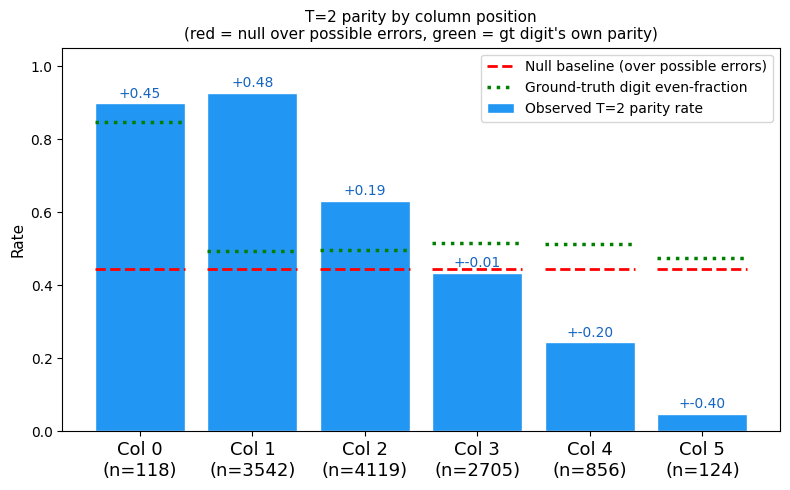

[np.float64(0.8983050847457628), np.float64(0.9271597967250141), np.float64(0.6314639475600874), np.float64(0.4343807763401109), np.float64(0.2441588785046729), np.float64(0.04838709677419355)]
Column  n       Observed    NullErr     GT-even     Gap(vsNull) 
0       118     0.898       0.444       0.847       0.454       
1       3542    0.927       0.444       0.495       0.483       
2       4119    0.631       0.444       0.496       0.187       
3       2705    0.434       0.444       0.515       -0.010      
4       856     0.244       0.444       0.513       -0.200      
5       124     0.048       0.444       0.476       -0.396      


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

def compute_column_null_baseline(gt_digits_wrong):
    """Data-derived null: for each gt digit that appears as an error, what
    fraction of the 9 possible wrong digits would be even, averaged."""
    null_rates = []
    for gt_d in gt_digits_wrong:
        possible_digits = [d for d in range(10) if d != gt_d]
        possible_errors = [d - gt_d for d in possible_digits]
        even_frac = sum(1 for e in possible_errors if e % 2 == 0) / len(possible_errors)
        null_rates.append(even_frac)
    return np.mean(null_rates)


n_columns = 6

# Define 'fail' as the boolean array of incorrect predictions
fail = ~correct_arr

col_parities   = []  # observed error-offset parity rate
col_null_rates = []  # data-derived null over possible errors
col_gt_even    = []  # ground-truth digit's own even-fraction
col_ns         = []
col_labels     = []

for k in range(n_columns):
    gt_digit_k   = (ground_truths_arr // (10**k)) % 10
    safe_pred    = np.where(model_answers_arr < 0, -999, model_answers_arr)
    pred_digit_k = (safe_pred // (10**k)) % 10
    valid        = model_answers_arr >= 0
    digit_wrong  = gt_digit_k != pred_digit_k
    mask         = fail & valid & digit_wrong

    if mask.sum() < 3:
        continue

    errs = pred_digit_k[mask] - gt_digit_k[mask]
    observed_parity = (errs % 2 == 0).mean()
    null_baseline = compute_column_null_baseline(gt_digit_k[mask])
    gt_even_frac = (gt_digit_k[mask] % 2 == 0).mean()

    col_parities.append(observed_parity)
    col_null_rates.append(null_baseline)
    col_gt_even.append(gt_even_frac)
    col_ns.append(mask.sum())
    col_labels.append(f"Col {k}\n(n={mask.sum()})")

# ── Plot: bars = observed, red ticks = null-over-errors, green ticks = gt parity ─
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(col_parities))
ax.bar(x, col_parities, color="#2196F3", edgecolor="white",
       label="Observed T=2 parity rate", zorder=2)

for xi, null_val in zip(x, col_null_rates):
    ax.plot([xi - 0.4, xi + 0.4], [null_val, null_val],
            color="red", linestyle="--", linewidth=2, zorder=3)

for xi, gt_val in zip(x, col_gt_even):
    ax.plot([xi - 0.4, xi + 0.4], [gt_val, gt_val],
            color="green", linestyle=":", linewidth=2.5, zorder=3)

# Proxy artists for legend
ax.plot([], [], color="red", linestyle="--", linewidth=2,
        label="Null baseline (over possible errors)")
ax.plot([], [], color="green", linestyle=":", linewidth=2.5,
        label="Ground-truth digit even-fraction")

for xi, obs, null_val in zip(x, col_parities, col_null_rates):
    ax.annotate(f"+{obs - null_val:.2f}", xy=(xi, obs), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=10, color="#1565C0")

ax.set_xticks(x)
ax.set_xticklabels(col_labels, fontsize=13)
ax.set_ylabel("Rate", fontsize=11)
ax.set_title("T=2 parity by column position\n"
             "(red = null over possible errors, green = gt digit's own parity)",
             fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(MULT_CACHE_DIR, "t2_parity_by_column_adapted_baseline.png"), dpi=150)
plt.show()
print(col_parities)
print(f"{'Column':<8}{'n':<8}{'Observed':<12}{'NullErr':<12}{'GT-even':<12}{'Gap(vsNull)':<12}")
for k, (obs, null_val, gt_val, n) in enumerate(zip(col_parities, col_null_rates, col_gt_even, col_ns)):
    print(f"{k:<8}{n:<8}{obs:<12.3f}{null_val:<12.3f}{gt_val:<12.3f}{obs-null_val:<12.3f}")

In [ ]:
# ============================================================================
# BLOCK: Statistical significance for parity-by-column figure
#
# Tests, per column: is the observed parity-preservation rate significantly
# above BOTH baselines (null-over-possible-errors, gt-digit-even-fraction)?
# Binomial test is appropriate here — each error is an independent Bernoulli
# trial (parity preserved / not), and we're testing whether the observed
# proportion differs from a specific hypothesized proportion.
# ============================================================================
import numpy as np
from scipy import stats

def parity_significance_table(col_parities, col_null_rates, col_gt_even, col_ns,
                                col_labels):
    """
    For each column, run a one-sided binomial test against both baselines
    and report a Wilson score confidence interval for the observed rate
    (more reliable than a normal-approximation CI at extreme proportions,
    which several of your columns have — e.g. col 5 at ~8%).
    """
    rows = []
    for k, (obs, null_val, gt_val, n, label) in enumerate(
            zip(col_parities, col_null_rates, col_gt_even, col_ns, col_labels)):

        n_successes = int(round(obs * n))

        # One-sided binomial test: is observed > baseline?
        # (use greater/less depending on direction; report whichever is
        # relevant — for low columns you expect "greater", for high
        # columns the effect reverses, so test both directions and report
        # the meaningful one)
        p_vs_null = stats.binomtest(n_successes, n, null_val,
                                      alternative='two-sided').pvalue
        p_vs_gt   = stats.binomtest(n_successes, n, gt_val,
                                      alternative='two-sided').pvalue

        # Wilson score CI (95%) — robust at small n and extreme proportions
        ci_low, ci_high = stats.binomtest(
            n_successes, n).proportion_ci(confidence_level=0.95, method='wilson')

        rows.append({
            "column": label.split("\n")[0],
            "n": n,
            "observed": obs,
            "ci_95_low": ci_low,
            "ci_95_high": ci_high,
            "null_baseline": null_val,
            "p_vs_null": p_vs_null,
            "gt_even_baseline": gt_val,
            "p_vs_gt_even": p_vs_gt,
            "sig_vs_null": "***" if p_vs_null < 0.001 else
                           "**" if p_vs_null < 0.01 else
                           "*" if p_vs_null < 0.05 else "ns",
        })

    return rows


sig_table = parity_significance_table(col_parities, col_null_rates, col_gt_even,
                                        col_ns, col_labels)

print(f"{'Col':<6}{'n':<7}{'Obs':<8}{'95% CI':<18}{'Null':<8}{'p(vs null)':<12}{'Sig':<6}")
for r in sig_table:
    ci_str = f"[{r['ci_95_low']:.3f},{r['ci_95_high']:.3f}]"
    p_str = f"{r['p_vs_null']:.2e}" if r['p_vs_null'] < 0.001 else f"{r['p_vs_null']:.4f}"
    print(f"{r['column']:<6}{r['n']:<7}{r['observed']:<8.3f}{ci_str:<18}"
          f"{r['null_baseline']:<8.3f}{p_str:<12}{r['sig_vs_null']:<6}")

Col   n      Obs     95% CI            Null    p(vs null)  Sig   
Col 0 118    0.898   [0.831,0.941]     0.444   4.84e-25    ***   
Col 1 3542   0.927   [0.918,0.935]     0.444   0.00e+00    ***   
Col 2 4119   0.631   [0.617,0.646]     0.444   3.24e-128   ***   
Col 3 2705   0.434   [0.416,0.453]     0.444   0.2962      ns    
Col 4 856    0.244   [0.217,0.274]     0.444   6.21e-34    ***   
Col 5 124    0.048   [0.022,0.102]     0.444   3.31e-23    ***   


In [ ]:
# ============================================================================
# BLOCK: Mean relative error with confidence interval
#
# Uses bootstrap CI rather than a normal-approximation CI, since relative
# error is typically right-skewed (bounded below at 0, long tail), so a
# symmetric CI would be misleading.
# ============================================================================

def relative_error_stats(model_answers_arr, ground_truths_arr, correct_arr=None,
                           n_bootstrap=10000, seed=42):
    valid = model_answers_arr >= 0
    rel_err = np.abs(model_answers_arr[valid] - ground_truths_arr[valid]) / \
              ground_truths_arr[valid]

    mean_rel_err = rel_err.mean()
    median_rel_err = np.median(rel_err)

    rng = np.random.default_rng(seed)
    boot_means = np.array([
        rng.choice(rel_err, size=len(rel_err), replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

    print(f"Mean relative error:   {mean_rel_err:.4f} "
          f"(95% bootstrap CI: [{ci_low:.4f}, {ci_high:.4f}])")
    print(f"Median relative error: {median_rel_err:.4f}")
    print(f"n = {valid.sum()}")

    return {"mean": mean_rel_err, "median": median_rel_err,
            "ci_low": ci_low, "ci_high": ci_high, "n": int(valid.sum())}


# Per-category breakdown too — useful for the slide, shows error doesn't
# blow up uniformly across tiers
def relative_error_by_category(model_answers_arr, ground_truths_arr, categories_arr):
    results = {}
    for cat in np.unique(categories_arr):
        mask = (categories_arr == cat) & (model_answers_arr >= 0)
        if mask.sum() < 5:
            continue
        rel_err = np.abs(model_answers_arr[mask] - ground_truths_arr[mask]) / \
                   ground_truths_arr[mask]
        results[cat] = {"mean": rel_err.mean(), "median": np.median(rel_err),
                         "n": int(mask.sum())}
    return results

overall_stats = relative_error_stats(model_answers_arr, ground_truths_arr)
by_cat_stats = relative_error_by_category(model_answers_arr, ground_truths_arr, categories_arr)

print(f"\n{'Category':<10}{'n':<8}{'Mean RelErr':<14}{'Median RelErr':<14}")
for cat, s in sorted(by_cat_stats.items()):
    print(f"{cat:<10}{s['n']:<8}{s['mean']:<14.4f}{s['median']:<14.4f}")

Mean relative error:   0.6520 (95% bootstrap CI: [0.0043, 1.8881])
Median relative error: 0.0000
n = 16991

Category  n       Mean RelErr   Median RelErr 
1x1       81      0.0000        0.0000        
1x2       810     0.0001        0.0000        
2x2       8100    0.0050        0.0000        
2x3       3000    0.0033        0.0000        
2x4       1000    11.0060       0.0000        
3x3       3000    0.0041        0.0023        
3x4       1000    0.0090        0.0015        


In [ ]:
# ============================================================================
# BLOCK: Full error-type categorization per column
#
# For each column, classifies every wrong digit by:
#   - off_by_multiple_of_10 status (already established finding — this
#     confirms it per-column too, not just globally)
#   - sign of error (over- vs under-prediction)
#   - magnitude bucket (±1, ±2, ±3-4, ±5+)
#   - parity preserved / violated
# ============================================================================
import pandas as pd

def categorize_column_errors(ground_truths_arr, model_answers_arr, fail,
                               n_columns=6):
    rows = []
    for k in range(n_columns):
        gt_digit_k   = (ground_truths_arr // (10**k)) % 10
        safe_pred    = np.where(model_answers_arr < 0, -999, model_answers_arr)
        pred_digit_k = (safe_pred // (10**k)) % 10
        valid        = model_answers_arr >= 0
        digit_wrong  = gt_digit_k != pred_digit_k
        mask         = fail & valid & digit_wrong

        if mask.sum() < 3:
            continue

        errs = pred_digit_k[mask] - gt_digit_k[mask]
        abs_errs = np.abs(errs)

        def bucket(e):
            if e == 1: return "±1"
            if e == 2: return "±2"
            if 3 <= e <= 4: return "±3-4"
            return "±5+"

        buckets = [bucket(e) for e in abs_errs]
        bucket_counts = pd.Series(buckets).value_counts(normalize=True)

        rows.append({
            "column": k,
            "n_errors": int(mask.sum()),
            "parity_preserved_pct": (errs % 2 == 0).mean() * 100,
            "over_predict_pct": (errs > 0).mean() * 100,
            "under_predict_pct": (errs < 0).mean() * 100,
            "pct_off_by_1": bucket_counts.get("±1", 0) * 100,
            "pct_off_by_2": bucket_counts.get("±2", 0) * 100,
            "pct_off_by_3_4": bucket_counts.get("±3-4", 0) * 100,
            "pct_off_by_5plus": bucket_counts.get("±5+", 0) * 100,
            "mean_abs_offset": abs_errs.mean(),
        })

    return pd.DataFrame(rows)


error_categorization = categorize_column_errors(ground_truths_arr, model_answers_arr, fail)
print(error_categorization.round(1).to_string(index=False))

error_categorization.to_csv(os.path.join(MULT_CACHE_DIR, "error_categorization_by_column.csv"),
                              index=False)

 column  n_errors  parity_preserved_pct  over_predict_pct  under_predict_pct  pct_off_by_1  pct_off_by_2  pct_off_by_3_4  pct_off_by_5plus  mean_abs_offset
      0       118                  89.8              29.7               70.3           0.8          37.3            17.8              44.1              4.4
      1      3542                  92.7              47.2               52.8           2.2          43.2            25.1              29.4              3.9
      2      4119                  63.1              52.3               47.7          30.6          30.4            16.3              22.7              3.2
      3      2705                  43.4              55.4               44.6          40.4          23.9            14.3              21.4              2.9
      4       856                  24.4              51.4               48.6          64.0          15.4             7.9              12.6              2.2
      5       124                   4.8              36.3       

Category     n Accuracy Parse failures
     1x1    81   100.0%          0.00%
     1x2   810    84.8%          0.00%
     2x2  8100    76.4%          0.00%
     2x3  3000    35.0%          0.00%
     2x4  1000    23.7%          0.00%
     3x3  3000     9.3%          0.00%
     3x4  1000     3.1%          0.00%
 OVERALL 16991    50.4%          0.00%


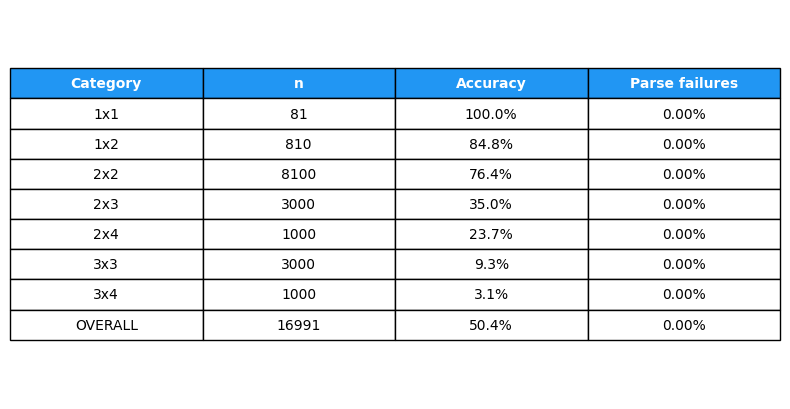

In [ ]:
# ============================================================================
# BLOCK: Accuracy table for the slide — clean, presentation-ready
# ============================================================================

def build_accuracy_table(categories_arr, correct_arr, model_answers_arr):
    rows = []
    for cat in sorted(np.unique(categories_arr)):
        mask = categories_arr == cat
        n = mask.sum()
        acc = correct_arr[mask].mean()
        parse_fail = (model_answers_arr[mask] == -1).mean()

        # Wilson CI on accuracy itself — useful to show precision, especially
        # for smaller tiers (2x4, 3x4)
        ci_low, ci_high = stats.binomtest(
            int(round(acc * n)), n).proportion_ci(confidence_level=0.95, method='wilson')

        rows.append({
            "Category": cat,
            "n": n,
            "Accuracy": f"{acc*100:.1f}%",
            #"95% CI": f"[{ci_low*100:.1f}%, {ci_high*100:.1f}%]",
            "Parse failures": f"{parse_fail*100:.2f}%",
        })

    overall_acc = correct_arr.mean()
    overall_n = len(correct_arr)
    ci_low, ci_high = stats.binomtest(
        int(round(overall_acc * overall_n)), overall_n).proportion_ci(
        confidence_level=0.95, method='wilson')
    rows.append({
        "Category": "OVERALL",
        "n": overall_n,
        "Accuracy": f"{overall_acc*100:.1f}%",
        #"95% CI": f"[{ci_low*100:.1f}%, {ci_high*100:.1f}%]",
        "Parse failures": f"{(model_answers_arr==-1).mean()*100:.2f}%",
    })

    return pd.DataFrame(rows)


accuracy_table = build_accuracy_table(categories_arr, correct_arr, model_answers_arr)
print(accuracy_table.to_string(index=False))

accuracy_table.to_csv(os.path.join(MULT_CACHE_DIR, "accuracy_table.csv"), index=False)

# Optional: render directly as a matplotlib table image for a clean PowerPoint
# paste (avoids manually rebuilding the table in PPT)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 0.4 * len(accuracy_table) + 1))
ax.axis('off')
tbl = ax.table(cellText=accuracy_table.values, colLabels=accuracy_table.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)
for j in range(len(accuracy_table.columns)):
    tbl[0, j].set_facecolor("#2196F3")
    tbl[0, j].set_text_props(color="white", weight="bold")
plt.tight_layout()
plt.savefig(os.path.join(MULT_CACHE_DIR, "accuracy_table.png"), dpi=200, bbox_inches='tight')
plt.show()

 column column_label     n  n_correct  accuracy  ci_low  ci_high
      0         10^0 16991      14831    0.8729  0.8678   0.8778
      1         10^1 16968      10809    0.6370  0.6298   0.6442
      2         10^2 16714       9423    0.5638  0.5562   0.5713
      3         10^3 14610       8887    0.6083  0.6003   0.6162
      4         10^4  7441       3986    0.5357  0.5243   0.5470
      5         10^5  4314       2696    0.6249  0.6104   0.6393
      6         10^6   840        310    0.3690  0.3371   0.4022


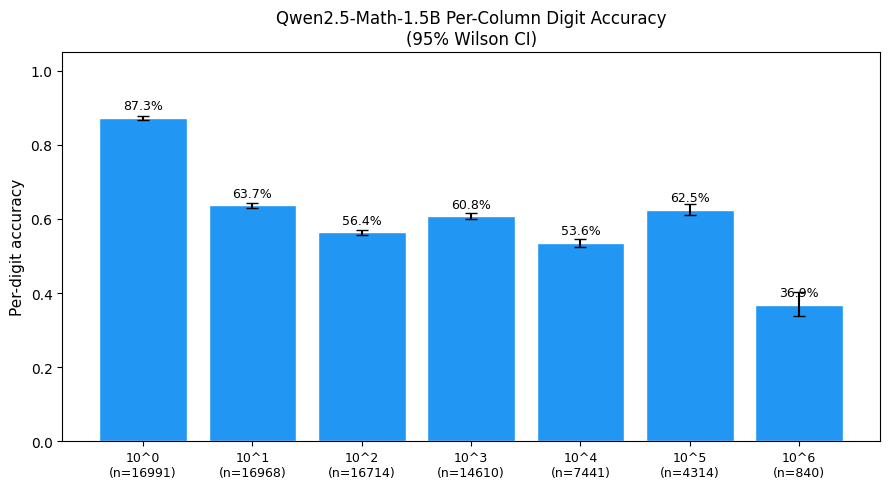

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

def per_column_digit_accuracy(model_answers_arr, ground_truths_arr, n_columns=8):
    """
    For each column k (0=units, 1=tens, ...), compute the proportion of
    examples where that digit is correct, aggregated across the WHOLE
    dataset — not conditioned on overall correctness or failure, so this
    includes examples that are right elsewhere but wrong at this digit,
    and vice versa.

    Only examples where the ground truth actually HAS a digit at column k
    are counted (shorter products don't have a hundreds digit, etc.) —
    excluding them rather than padding with false zeros.
    """
    valid = model_answers_arr >= 0  # exclude parse failures entirely
    safe_pred = np.where(model_answers_arr < 0, -999, model_answers_arr)

    rows = []
    for k in range(n_columns):
        # A ground truth "has" a digit at column k if it's at least 10^k
        # in magnitude (i.e. the digit isn't a leading zero that doesn't exist)
        has_digit_k = ground_truths_arr >= (10 ** k)
        mask = valid & has_digit_k

        if mask.sum() == 0:
            continue

        gt_digit_k = (ground_truths_arr[mask] // (10**k)) % 10
        pred_digit_k = (safe_pred[mask] // (10**k)) % 10

        n_total = mask.sum()
        n_correct = (gt_digit_k == pred_digit_k).sum()
        acc = n_correct / n_total

        ci_low, ci_high = stats.binomtest(
            int(n_correct), n_total).proportion_ci(
            confidence_level=0.95, method='wilson')

        rows.append({
            "column": k,
            "column_label": f"10^{k}",
            "n": n_total,
            "n_correct": n_correct,
            "accuracy": acc,
            "ci_low": ci_low,
            "ci_high": ci_high,
        })

    return pd.DataFrame(rows)


col_accuracy = per_column_digit_accuracy(model_answers_arr, ground_truths_arr)
print(col_accuracy.round(4).to_string(index=False))
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(col_accuracy))
bars = ax.bar(x, col_accuracy["accuracy"], color="#2196F3", edgecolor="white",
              yerr=[col_accuracy["accuracy"] - col_accuracy["ci_low"],
                    col_accuracy["ci_high"] - col_accuracy["accuracy"]],
              capsize=4, zorder=2)

for xi, row in zip(x, col_accuracy.itertuples()):
    ax.annotate(f"{row.accuracy:.1%}", xy=(xi, row.accuracy), xytext=(0, 6),
                textcoords="offset points", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"{row.column_label}\n(n={row.n})"
                     for row in col_accuracy.itertuples()], fontsize=9)
ax.set_ylabel("Per-digit accuracy", fontsize=11)
ax.set_title(f"{model_checkpoint_str} Per-Column Digit Accuracy\n(95% Wilson CI)", fontsize=12)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(MULT_CACHE_DIR, "per_column_digit_accuracy.png"), dpi=150)
plt.show()

In [ ]:
# ============================================================================
# BLOCK: Cross-model comparison table — accuracy vs. tens-column parity
#
# Uses ONLY previously saved arrays under ./mult_baseline/{model}/ — does not
# re-run generation. Restricted to a fixed set of models for the paper table.
#
# Reports the TENS column only (k=1). Unlike the units column, the tens
# digit's ground-truth parity isn't skewed by multiplication structure in
# the same way, so it's the cleaner single-column comparison for the main
# table. The null baseline is data-derived (not a flat 50%): for each
# ground-truth digit that appears in an error, the fraction of the 9
# possible wrong digits that would be even, averaged over the actual
# errors observed — this is the ~44% figure, not 50%.
# ============================================================================
import os
import numpy as np
import pandas as pd

MULT_BASELINE_DIR = "./mult_baseline"
REQUIRED_FILES    = ["model_answers.npy", "ground_truths.npy",
                      "categories.npy", "correct.npy"]
TENS_COLUMN       = 1

MODELS = [
    "Qwen3.5-2B",
    "Qwen3.5-0.8B",
    "Llama-3.2-3B",
    "Qwen2.5-Math-1.5B",
    "gemma-4-E2B",
]


def load_model_arrays(model_dir):
    paths = {f: os.path.join(model_dir, f) for f in REQUIRED_FILES}
    if not all(os.path.exists(p) for p in paths.values()):
        return None
    return {
        "model_answers": np.load(paths["model_answers.npy"], allow_pickle=True),
        "ground_truths": np.load(paths["ground_truths.npy"], allow_pickle=True),
        "categories":    np.load(paths["categories.npy"],    allow_pickle=True),
        "correct":       np.load(paths["correct.npy"],       allow_pickle=True),
    }


def compute_column_null_baseline(gt_digits_wrong):
    """Data-derived null: for each gt digit that appears as an error, what
    fraction of the 9 possible wrong digits would be even, averaged."""
    if len(gt_digits_wrong) == 0:
        return np.nan
    null_rates = []
    for gt_d in gt_digits_wrong:
        possible_digits = [d for d in range(10) if d != gt_d]
        possible_errors = [d - gt_d for d in possible_digits]
        even_frac = sum(1 for e in possible_errors if e % 2 == 0) / len(possible_errors)
        null_rates.append(even_frac)
    return np.mean(null_rates)


def tens_column_parity_stats(model_answers_arr, ground_truths_arr, correct_arr,
                               k=TENS_COLUMN):
    """Observed parity-preservation rate and data-derived null for the tens column."""
    fail  = ~correct_arr
    valid = model_answers_arr >= 0
    safe_pred = np.where(model_answers_arr < 0, -999, model_answers_arr)

    gt_digit_k   = (ground_truths_arr // (10 ** k)) % 10
    pred_digit_k = (safe_pred // (10 ** k)) % 10
    digit_wrong  = gt_digit_k != pred_digit_k
    mask         = fail & valid & digit_wrong

    n_wrong = int(mask.sum())
    if n_wrong == 0:
        return np.nan, np.nan, 0

    errs = pred_digit_k[mask] - gt_digit_k[mask]
    observed = (errs % 2 == 0).mean()
    null_baseline = compute_column_null_baseline(gt_digit_k[mask])
    return observed, null_baseline, n_wrong


rows = []
if not os.path.isdir(MULT_BASELINE_DIR):
    print(f"⚠️  {MULT_BASELINE_DIR} not found — check MULT_CACHE_DIR base path.")
else:
    for model_name in MODELS:
        model_dir = os.path.join(MULT_BASELINE_DIR, model_name)
        if not os.path.isdir(model_dir):
            print(f"  skipping {model_name}: no cached folder found at {model_dir}")
            continue

        arrs = load_model_arrays(model_dir)
        if arrs is None:
            print(f"  skipping {model_name}: missing one or more cached arrays")
            continue

        model_answers_arr = arrs["model_answers"]
        ground_truths_arr = arrs["ground_truths"]
        correct_arr        = arrs["correct"]

        n_total = len(correct_arr)
        acc     = correct_arr.mean()

        tens_obs, tens_null, tens_n = tens_column_parity_stats(
            model_answers_arr, ground_truths_arr, correct_arr)

        rows.append({
            "Model": model_name,
            "N": n_total,
            "Accuracy": acc,
            "Tens Parity Preservation": tens_obs,
            "Tens Null Baseline": tens_null,
            "N_wrong_digits": tens_n,
        })

comparison_df = pd.DataFrame(rows)

if comparison_df.empty:
    print("No complete model result sets found for the requested models.")
else:
    display_df = comparison_df.copy()
    for col in ["Accuracy", "Tens Parity Preservation", "Tens Null Baseline"]:
        display_df[col] = (display_df[col] * 100).round(1).astype(str) + "%"

    print(display_df[["Model", "N", "Accuracy",
                       "Tens Parity Preservation", "Tens Null Baseline",
                       "N_wrong_digits"]].to_string(index=False))

    out_dir = os.path.join(MULT_BASELINE_DIR, "_comparison")
    os.makedirs(out_dir, exist_ok=True)
    comparison_df.to_csv(os.path.join(out_dir, "model_comparison.csv"), index=False)

    latex_df = comparison_df[["Model", "N", "Accuracy",
                               "Tens Parity Preservation",
                               "Tens Null Baseline"]].copy()
    for col in ["Accuracy", "Tens Parity Preservation", "Tens Null Baseline"]:
        latex_df[col] = (latex_df[col] * 100).round(1)
    latex_df.columns = ["Model", "$n$", "Accuracy (\\%)",
                         "Tens Parity Pres.\\ (\\%)", "Null Baseline (\\%)"]

    latex_str = latex_df.to_latex(
        index=False, float_format="%.1f", escape=False,
        caption=("Overall multiplication accuracy and tens-column parity-"
                 "preservation rate across models, alongside the data-"
                 "derived null baseline ($\\sim$44\\%, not 50\\%, since "
                 "chance-level parity preservation depends on the "
                 "ground-truth digit distribution among observed errors)."),
        label="tab:model_comparison"
    )

    with open(os.path.join(out_dir, "model_comparison.tex"), "w") as f:
        f.write(latex_str)

    print(f"\n✅ Saved CSV  -> {os.path.join(out_dir, 'model_comparison.csv')}")
    print(f"✅ Saved LaTeX -> {os.path.join(out_dir, 'model_comparison.tex')}")
    print("\n--- LaTeX preview ---\n")
    print(latex_str)

            Model     N Accuracy Tens Parity Preservation Tens Null Baseline  N_wrong_digits
       Qwen3.5-2B 16991    56.4%                    92.7%              44.4%            3542
     Qwen3.5-0.8B 16991    60.8%                    69.5%              44.4%            4722
     Llama-3.2-3B 16991    25.0%                    45.2%              44.4%           11408
Qwen2.5-Math-1.5B 16991    50.4%                    67.9%              44.4%            6159
      gemma-4-E2B 16991    28.8%                    44.0%              44.4%           10704

✅ Saved CSV  -> ./mult_baseline/_comparison/model_comparison.csv
✅ Saved LaTeX -> ./mult_baseline/_comparison/model_comparison.tex

--- LaTeX preview ---

\begin{table}
\caption{Overall multiplication accuracy and tens-column parity-preservation rate across models, alongside the data-derived null baseline ($\sim$44\%, not 50\%, since chance-level parity preservation depends on the ground-truth digit distribution among observed errors).}
